In [195]:
import numpy as np
import pandas as pd

In [196]:
# Load the data
df = pd.read_csv('customer_shopping_behavior.csv')

In [197]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [198]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [199]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [200]:
# check missing values

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [201]:
# null value replace with median 
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [202]:
# again check null 
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [203]:
# Changing the column name in snake case 

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')


In [204]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [205]:
# changing column name

df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [206]:
# create a column age_group

labels = ['Young-Adult','Adult','Middle-Aged','Senior']
df['age_group'] = pd.qcut(df['age'],q = 4,labels=labels)

In [207]:
# check

df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-Aged
1,19,Young-Adult
2,50,Middle-Aged
3,21,Young-Adult
4,45,Middle-Aged
5,46,Middle-Aged
6,63,Senior
7,27,Young-Adult
8,26,Young-Adult
9,57,Middle-Aged


In [208]:
df['frequency_of_purchases'].unique()

<ArrowStringArray>
[   'Fortnightly',         'Weekly',       'Annually',      'Quarterly',
      'Bi-Weekly',        'Monthly', 'Every 3 Months']
Length: 7, dtype: str

In [209]:
# create column purchase_frequency_days

frequency_mapping = {
    'Fortnightly' : 14,
    'Weekly' : 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly' : 14,
    'Annually' : 365,
    'Every 3 Months' : 90
}

# replace the text into value using map 
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [210]:
# check
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [211]:
# both the columns has same data
df[['discount_applied','promo_code_used']].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [212]:
# check
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [213]:
# drop one column
df = df.drop('promo_code_used',axis = 1)
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

In [214]:
#  Which are the Top 10 most purchased items with their total revenue?

df.groupby('item_purchased')['purchase_amount'].sum().nlargest(10)

item_purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: purchase_amount, dtype: int64

In [245]:
df.groupby(['age_group', 'payment_method']).size().unstack().idxmax(axis=1)


age_group
Young-Adult           Cash
Adult                Venmo
Middle-Aged         PayPal
Senior         Credit Card
dtype: str

## SQL Analysis


In [216]:
# make a connection is postgreSQL

from sqlalchemy import create_engine

# step 1 : connect
username = 'postgres'
password = 'tiger'
host = 'localhost'
port = '5432'
database = 'customer_behaviour'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# step 2 : load the dataframe into postrge

table_name = 'customer' 
df.to_sql(table_name,engine,if_exists='replace',index = False)
print(f"Data successfully loaded into table '{table_name}' in database '{database}'")

Data successfully loaded into table 'customer' in database 'customer_behaviour'


In [217]:
# --Q1. What is the total revenue generated by male vs. female customers?

pd.read_sql("""
SELECT gender,
       SUM(purchase_amount) AS total_revenue
FROM customer
GROUP BY gender;
""", engine)

,gender,total_revenue
0,Female,75191.0
1,Male,157890.0


In [218]:
# --Q2. Which customers used a discount but still spent more than the average purchase amount? 

pd.read_sql("""
SELECT customer_id,purchase_amount
FROM customer
WHERE discount_applied ='Yes' AND purchase_amount >= (SELECT AVG(purchase_amount) FROM customer);""",engine)

,customer_id,purchase_amount
0,2,64
1,3,73
2,4,90
3,7,85
4,9,97
...,...,...
834,1667,64
835,1671,73
836,1673,73
837,1674,62


In [219]:
# -- Q3. Which are the top 5 products with the highest average review rating?

pd.read_sql("""
SELECT item_purchased,AVG(review_rating) as AverageproductRating
FROM customer
GROUP BY item_purchased
ORDER BY avg(review_rating) DESC
LIMIT 5;
""",engine)

,item_purchased,averageproductrating
0,Gloves,3.861429
1,Sandals,3.844375
2,Boots,3.818750
3,Hat,3.801299
4,Skirt,3.784810


In [220]:
pd.read_sql("""
SELECT ROUND(AVG(purchase_amount),2)
FROM customer
WHERE shipping_type in ('Standard','Express')
GROUP BY shipping_type;
""",engine)

,round
0,60.48
1,58.46


In [221]:
#--Q5. Do subscribed customers spend more? Compare average spend and total revenue 
#--between subscribers and non-subscribers.

pd.read_sql("""
SELECT subscription_status,
            COUNT(customer_id) as total_customer,
            ROUND(AVG(purchase_amount),2) as avg_spend,
            ROUND(SUM(purchase_amount),2) as total_revenue
FROM customer
GROUP BY subscription_status
ORDER BY total_revenue,avg_spend DESC;
""",engine)

,subscription_status,total_customer,avg_spend,total_revenue
0,Yes,1053,59.49,62645.0
1,No,2847,59.87,170436.0


In [222]:
# --Q6. Which 5 products have the highest percentage of purchases with discounts applied?

pd.read_sql("""
SELECT item_purchased,
            ROUND(100.0 * SUM(CASE WHEN discount_applied = 'Yes' THEN 1 ELSE 0 END )/COUNT(*),2) AS discount_rate
FROM customer
GROUP BY item_purchased
ORDER BY discount_rate DESC
LIMIT 5;
""",engine)

,item_purchased,discount_rate
0,Hat,50.00
1,Sneakers,49.66
2,Coat,49.07
3,Sweater,48.17
4,Pants,47.37


In [223]:
#--Q7. Segment customers into New, Returning, and Loyal based on their total 
#-- number of previous purchases, and show the count of each segment. 
pd.read_sql("""
with customer_type as (
SELECT customer_id, previous_purchases,
CASE 
    WHEN previous_purchases = 1 THEN 'New'
    WHEN previous_purchases BETWEEN 2 AND 10 THEN 'Returning'
    ELSE 'Loyal'
    END AS customer_segment
FROM customer)

select customer_segment,count(*) AS "Number of Customers" 
from customer_type 
group by customer_segment;
            
""",engine)

,customer_segment,Number of Customers
0,New,83
1,Returning,701
2,Loyal,3116


In [224]:
#--Q8. What are the top 3 most purchased products within each category? 
pd.read_sql("""
WITH item_counts AS (
    SELECT category,
           item_purchased,
           COUNT(customer_id) AS total_orders,
           ROW_NUMBER() OVER (PARTITION BY category ORDER BY COUNT(customer_id) DESC) AS item_rank
    FROM customer
    GROUP BY category, item_purchased
)
SELECT item_rank,category, item_purchased, total_orders
FROM item_counts
WHERE item_rank <=3;
""",engine)

,item_rank,category,item_purchased,total_orders
0,1,Accessories,Jewelry,171
1,2,Accessories,Sunglasses,161
2,3,Accessories,Belt,161
3,1,Clothing,Pants,171
4,2,Clothing,Blouse,171
5,3,Clothing,Shirt,169
6,1,Footwear,Sandals,160
7,2,Footwear,Shoes,150
8,3,Footwear,Sneakers,145
9,1,Outerwear,Jacket,163


In [225]:
 
#--Q9. Are customers who are repeat buyers (more than 5 previous purchases) also likely to subscribe?
pd.read_sql("""
SELECT subscription_status,
       COUNT(customer_id) AS repeat_buyers
FROM customer
WHERE previous_purchases > 5
GROUP BY subscription_status;
""",engine)

,subscription_status,repeat_buyers
0,No,2518
1,Yes,958


In [226]:
#--Q10. What is the revenue contribution of each age group? 

pd.read_sql("""
SELECT 
    age_group,
    SUM(purchase_amount) AS total_revenue
FROM customer
GROUP BY age_group
ORDER BY total_revenue desc;
""",engine)

,age_group,total_revenue
0,Young-Adult,62143.0
1,Middle-Aged,59197.0
2,Adult,55978.0
3,Senior,55763.0


## Visualization

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

---
### Q1. Total Revenue by Gender — Bar Chart

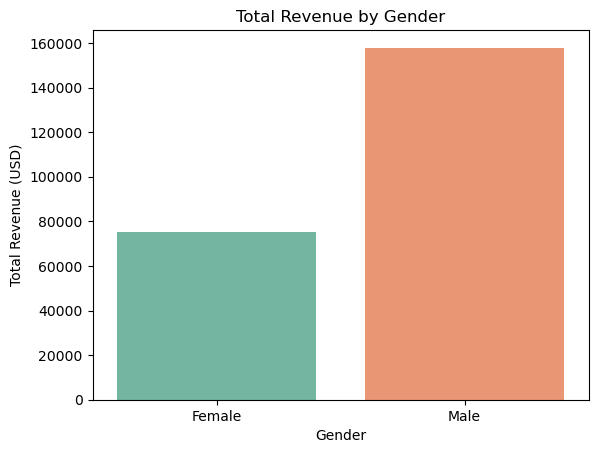

In [228]:
data = df.groupby('gender')['purchase_amount'].sum().reset_index()

sns.barplot(data=data, x='gender', y='purchase_amount', hue='gender', legend=False, palette='Set2')
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue (USD)')
plt.show()

---
### Q2. Top 10 Items by Total Revenue — Horizontal Bar Chart

In [229]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young-Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young-Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-Aged,365


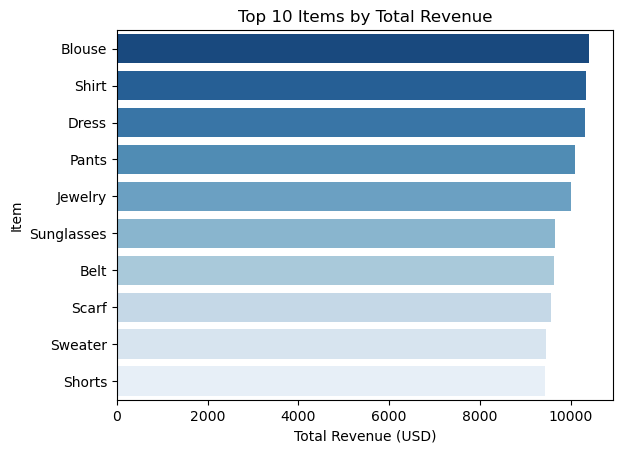

In [ ]:
data = df.groupby('item_purchased')['purchase_amount'].sum().nlargest(10).reset_index()


sns.barplot(data=data, y='item_purchased', x='purchase_amount',
            hue='item_purchased', legend=False, palette='Blues_r')
plt.title('Top 10 Items by Total Revenue')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

---
### Q3. Purchase Share by Category — Pie Chart

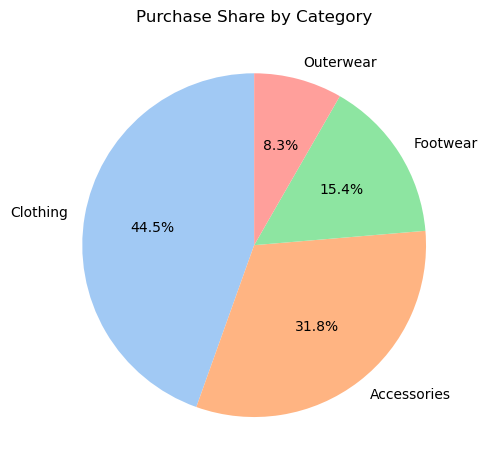

In [239]:
data = df['category'].value_counts()

plt.pie(data, labels=data.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Purchase Share by Category')
plt.tight_layout()
plt.show()

---
### Q4. Distribution of Purchase Amount — Histogram + KDE

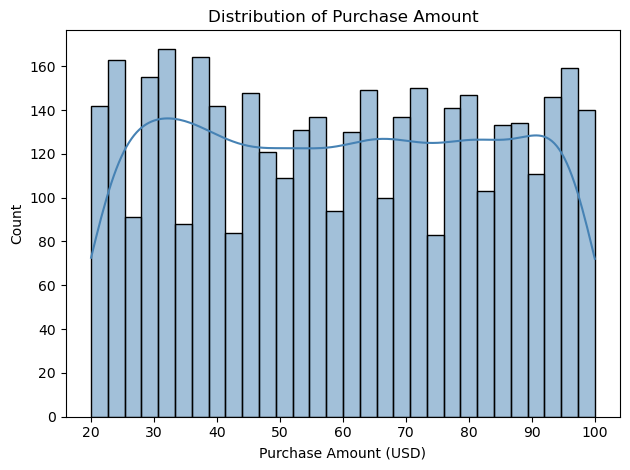

In [241]:
sns.histplot(df['purchase_amount'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
### Q5. Season-wise Total Revenue — Bar Chart

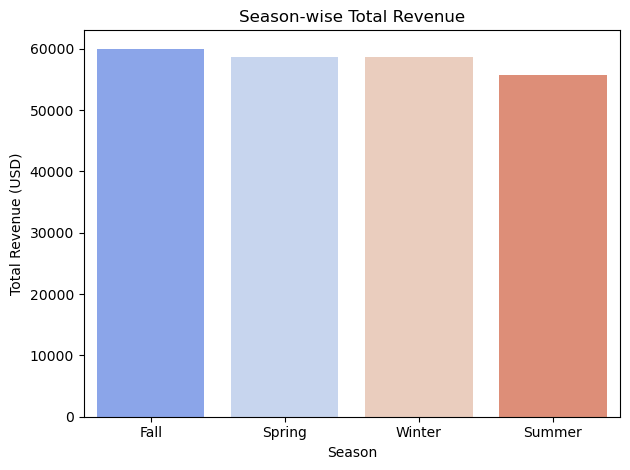

In [242]:
data = df.groupby('season')['purchase_amount'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=data, x='season', y='purchase_amount',
            hue='season', legend=False, palette='coolwarm')
plt.title('Season-wise Total Revenue')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

---
### Q6. Average Purchase Amount by Age Group — Bar Chart

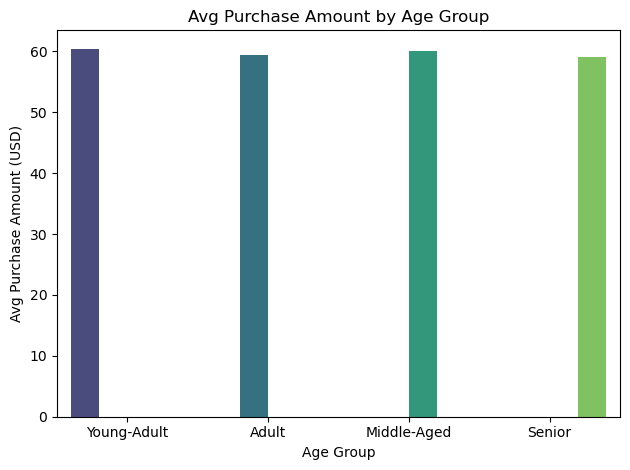

In [243]:
data = df.groupby('age_group', observed=True)['purchase_amount'].mean().reset_index()

sns.barplot(data=data, x='age_group', y='purchase_amount',
            hue='age_group', legend=False, palette='viridis')
plt.title('Avg Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Purchase Amount (USD)')
plt.tight_layout()
plt.show()

---
### Q7. Payment Method Distribution — Count Plot

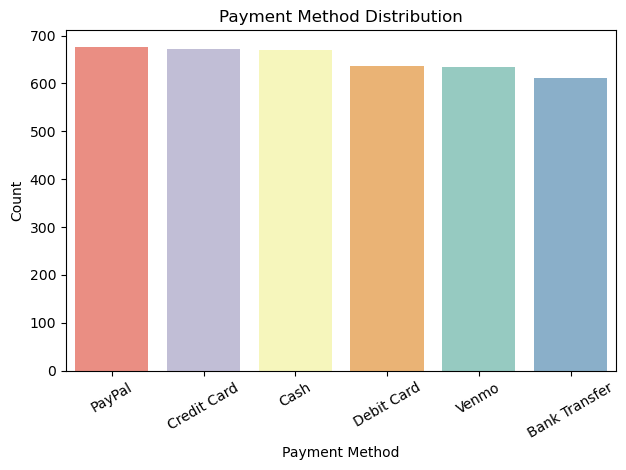

In [248]:
order = df['payment_method'].value_counts().index

sns.countplot(data=df, x='payment_method', hue='payment_method',
              order=order, legend=False, palette='Set3')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
### Q8. Avg Purchase Amount — Category vs Gender — Grouped Bar Chart

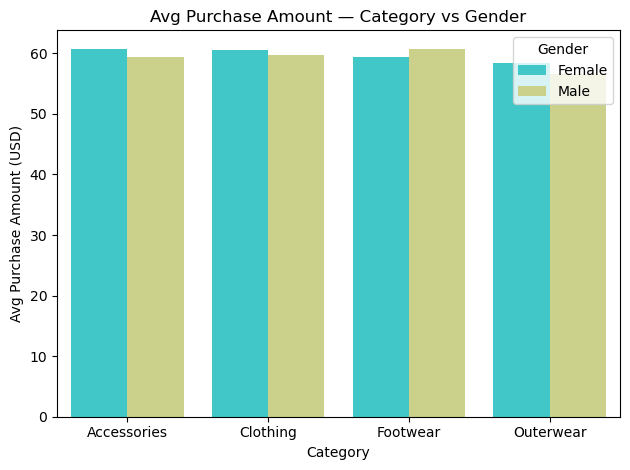

In [250]:
data = df.groupby(['category', 'gender'])['purchase_amount'].mean().reset_index()

sns.barplot(data=data, x='category', y='purchase_amount', hue='gender', palette='rainbow')
plt.title('Avg Purchase Amount — Category vs Gender')
plt.xlabel('Category')
plt.ylabel('Avg Purchase Amount (USD)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

---
### Q9. Review Rating by Category — Box Plot

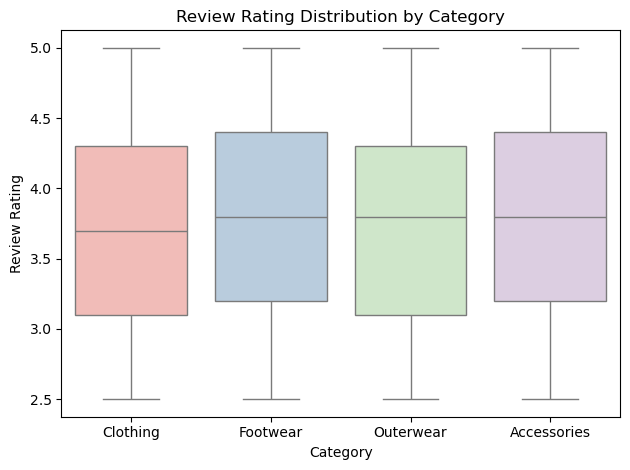

In [251]:
sns.boxplot(data=df, x='category', y='review_rating',
            hue='category', legend=False, palette='Pastel1')
plt.title('Review Rating Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Review Rating')
plt.tight_layout()
plt.show()

---
### Q10. Revenue by Season & Subscription Status — Grouped Bar Chart

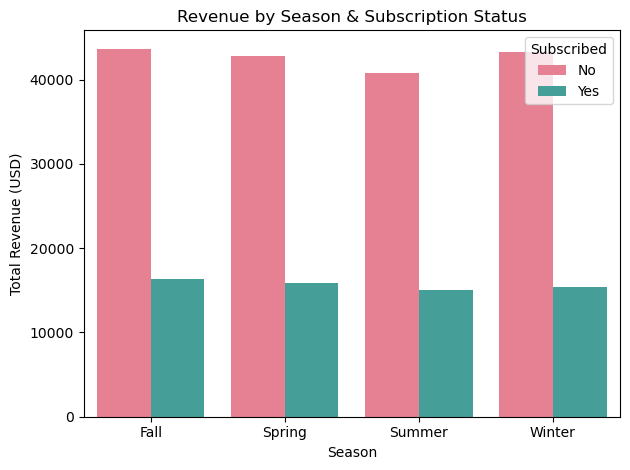

In [252]:
data = df.groupby(['season', 'subscription_status'])['purchase_amount'].sum().reset_index()

sns.barplot(data=data, x='season', y='purchase_amount',
            hue='subscription_status', palette='husl')
plt.title('Revenue by Season & Subscription Status')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()